# ARTI 404 - Image Processing
## Lab 3: Image Manipulations using OpenCV

**Student:** Abdullah Alnuwaysir  
**Course:** ARTI 404 - Image Processing  
**Lab:** 3

This lab applies the transformations required in the Student Procedural Manual using Python and OpenCV.

## Objectives
- Read and display an image using OpenCV.
- Apply geometric transformations: resize, rotation, and shear.
- Apply intensity transformations: negative, logarithmic, and power-law.

## 1. Import Libraries and Load the Image

Image shape: (600, 900, 3)
Data type: uint8


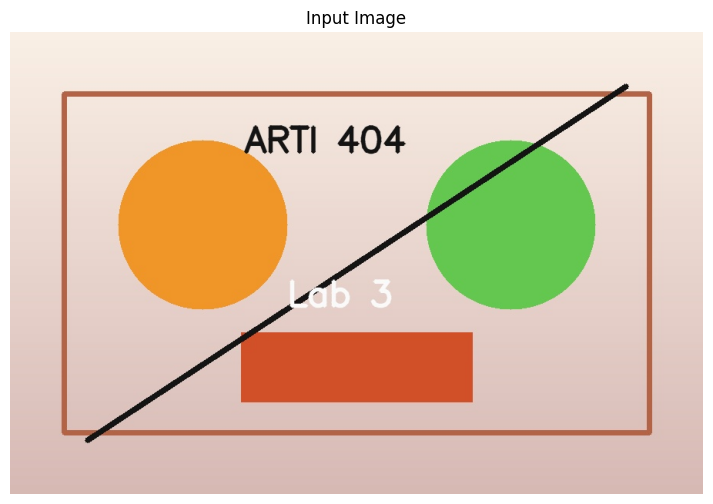

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGE_PATH = Path("images/input.jpg")
img = cv2.imread(str(IMAGE_PATH))

if img is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print("Image shape:", img.shape)
print("Data type:", img.dtype)

plt.figure(figsize=(9,6))
plt.imshow(img_rgb)
plt.title("Input Image")
plt.axis("off")
plt.show()

## Task 1 - Geometric Transformations

### 1. Increase the size of the image

Original size: (900, 600)
Resized size: (1350, 900)


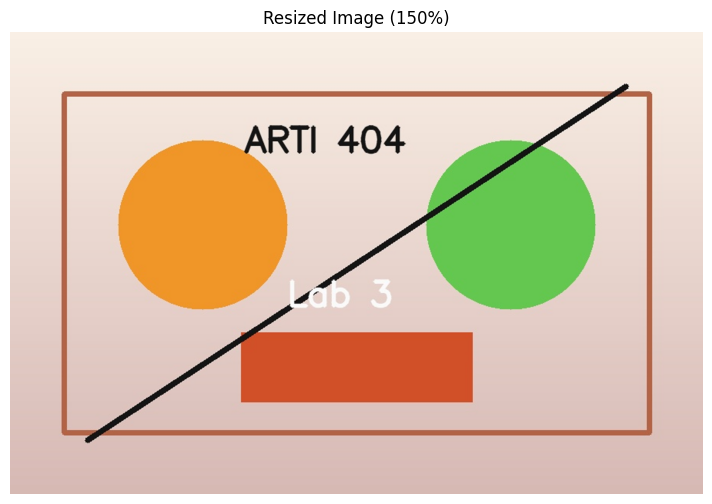

True

In [2]:
resized = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
print("Original size:", (img.shape[1], img.shape[0]))
print("Resized size:", (resized.shape[1], resized.shape[0]))

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized Image (150%)")
plt.axis("off")
plt.show()

cv2.imwrite("images/resized.jpg", resized)

### 2. Rotate the image by 120 degrees

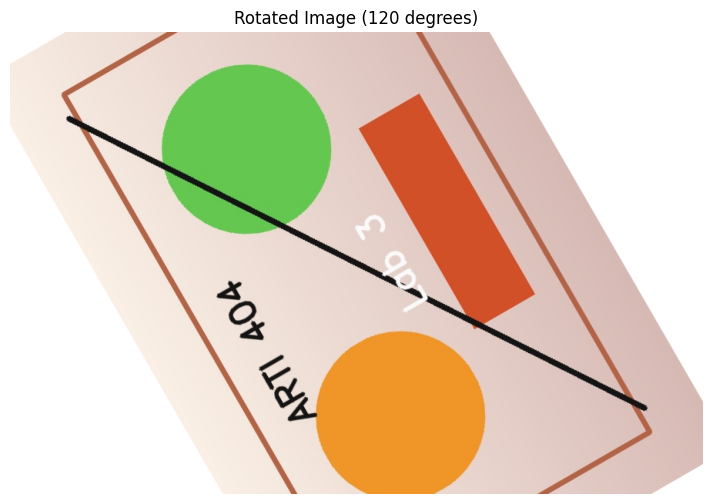

True

In [3]:
h, w = img.shape[:2]
center = (w // 2, h // 2)
Mrot = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated = cv2.warpAffine(
    img, Mrot, (w, h),
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(255, 255, 255)
)

plt.figure(figsize=(9,6))
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated Image (120 degrees)")
plt.axis("off")
plt.show()

cv2.imwrite("images/rotated_120.jpg", rotated)

### 3. Perform a shear operation

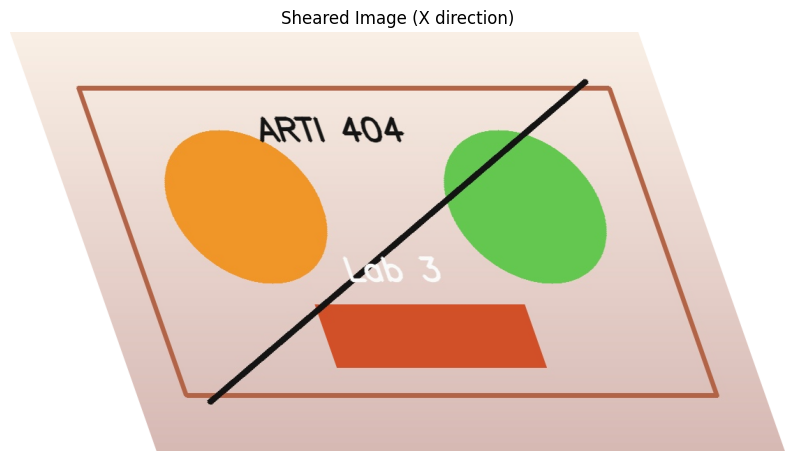

True

In [4]:
shear_factor = 0.35
Msh = np.float32([[1, shear_factor, 0], [0, 1, 0]])
sheared = cv2.warpAffine(
    img, Msh, (w + int(shear_factor * h), h),
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(255, 255, 255)
)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB))
plt.title("Sheared Image (X direction)")
plt.axis("off")
plt.show()

cv2.imwrite("images/sheared.jpg", sheared)

## Task 2 - Intensity Transformations

The intensity transformations are performed on the grayscale image.

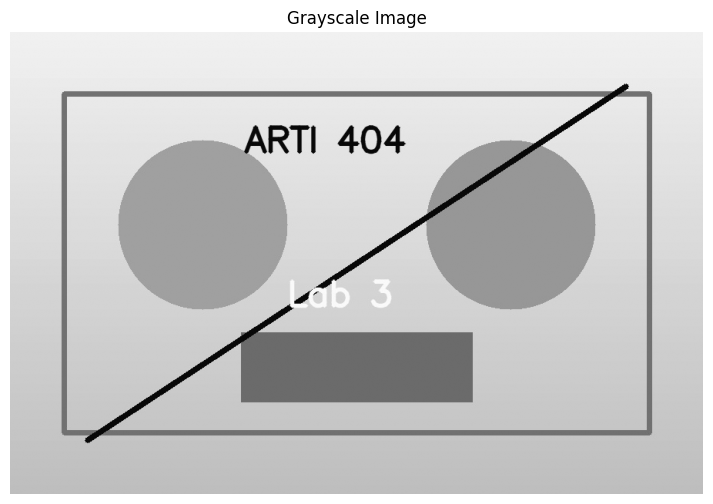

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(9,6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

### 1. Negative Image

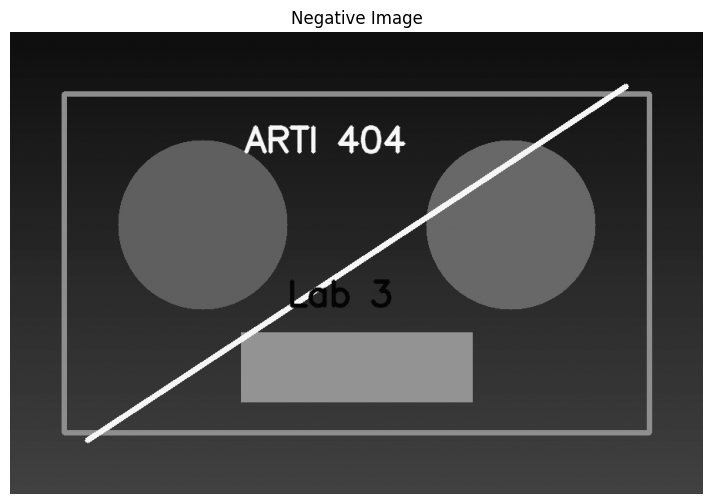

True

In [6]:
negative = 255 - gray

plt.figure(figsize=(9,6))
plt.imshow(negative, cmap="gray")
plt.title("Negative Image")
plt.axis("off")
plt.show()

cv2.imwrite("images/negative.jpg", negative)

### 2. Log Transformation

The constant is selected so the maximum output intensity is approximately 255.

Log transform constant c = 45.9859


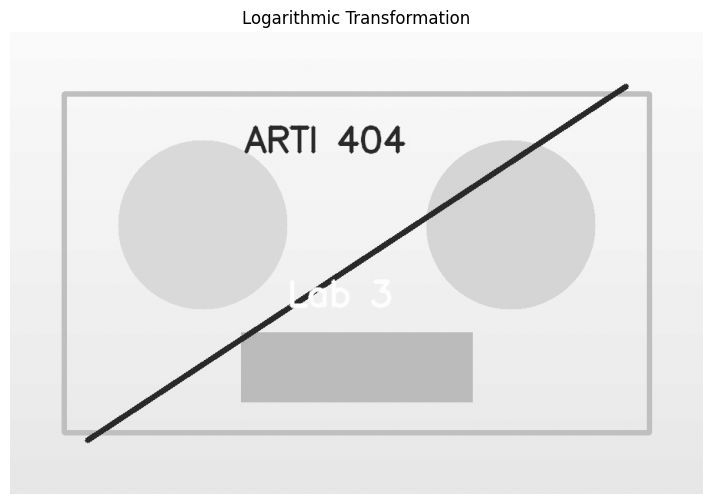

True

In [7]:
r = gray.astype(np.float32)
c = 255.0 / np.log1p(r.max())
log_img = c * np.log1p(r)
log_img = np.uint8(np.clip(log_img, 0, 255))

print("Log transform constant c =", round(float(c), 4))

plt.figure(figsize=(9,6))
plt.imshow(log_img, cmap="gray")
plt.title("Logarithmic Transformation")
plt.axis("off")
plt.show()

cv2.imwrite("images/log_transform.jpg", log_img)

### 3. Power-Law Transformation

A gamma value of **0.5** is used to enhance darker intensity levels and improve visual contrast in the image.

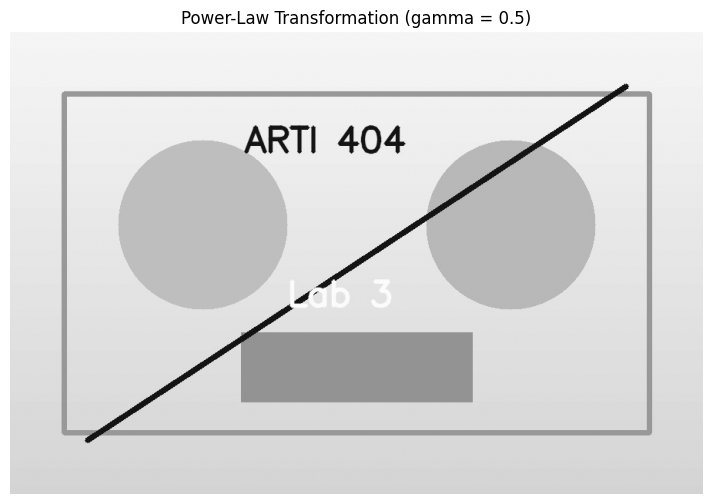

True

In [8]:
gamma = 0.5
normalized = gray.astype(np.float32) / 255.0
power_img = np.uint8(255 * np.power(normalized, gamma))

plt.figure(figsize=(9,6))
plt.imshow(power_img, cmap="gray")
plt.title("Power-Law Transformation (gamma = 0.5)")
plt.axis("off")
plt.show()

cv2.imwrite("images/power_law_gamma_0_5.jpg", power_img)

## Results / Observations

- **Resize:** the image dimensions increase by 50% while preserving the image content.
- **Rotation:** the image is rotated exactly **120 degrees** around its center.
- **Shear:** the image is slanted horizontally using an x-direction shear factor of **0.35**.
- **Negative:** bright pixels become dark and dark pixels become bright.
- **Log transform:** expands lower intensity values and compresses higher intensities.
- **Power-law:** with **gamma = 0.5**, darker regions become brighter, improving the visibility of details in those regions.

All required transformations from Lab 3 have been implemented using OpenCV.

## Conclusion

The lab demonstrates how OpenCV can be used to manipulate digital images through geometric and intensity transformations. The required operations were successfully applied, displayed, and saved as output image files.